# Estimation

## Weighing Penguins

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mode
from scipy.constants import pound

Weighing Penguins

In [2]:
sample = pd.Series(np.random.normal(0, 1, size=5000))
sample

0       0.631318
1       0.856294
2       1.793050
3      -0.108842
4       0.560586
          ...   
4995    0.040564
4996    0.966629
4997   -1.962278
4998   -0.428321
4999    1.060276
Length: 5000, dtype: float64

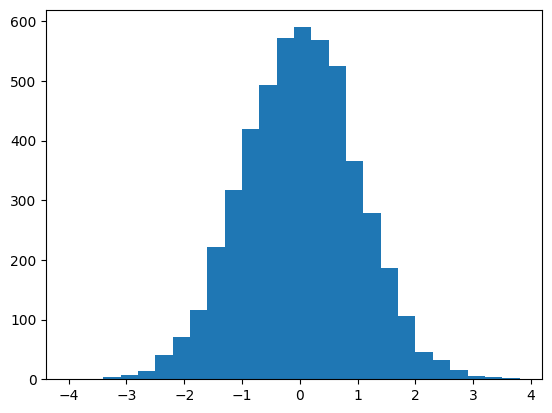

In [3]:
fig, ax = plt.subplots()
ax.hist(sample, bins=np.arange(-4, 4, 0.3))
plt.show()

In [4]:
np.mean(sample), np.std(sample)

(np.float64(0.0052241669461744475), np.float64(0.9921944947004717))

We didn't have to show it in graph but we can totally say that `np.random.normal` creates normally distributed numbers.

In [5]:
def make_normal_sample(mu, sigma, n):
    return np.random.normal(mu, sigma, n)

In [6]:
ns = np.logspace(1, 5).astype(int)

We are going to use these `n`s to see how the _estimator_ changes when the sample size increases.

In [7]:
mu = 3.7
sigma = 0.46

In [8]:
means = [np.mean(make_normal_sample(mu, sigma, n)) for n in ns]
medians = [np.median(make_normal_sample(mu, sigma, n)) for n in ns]

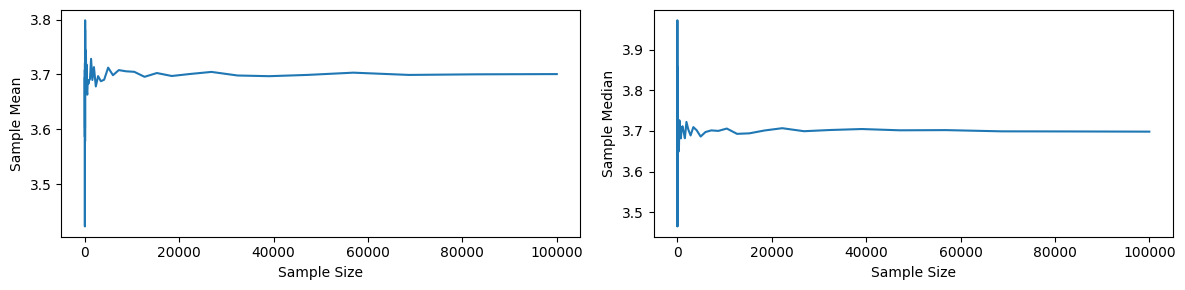

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(ns, means)
axes[1].plot(ns, medians)
axes[0].set_ylabel("Sample Mean")
axes[0].set_xlabel("Sample Size")
axes[1].set_ylabel("Sample Median")
axes[1].set_xlabel("Sample Size")
plt.tight_layout()
plt.show()

Right here, we've visualized the WLLN (Weak Law of Large Numbers) in action. We can also see that in a normal distribution, mean, median and the mode are perfectly equal in a normal distribution. But using the mean is usually preferred here because it is more statistically efficient.

**What is an estimator?** Simply put, an estimator is a rule or formula used to make an educated guess about a population parameter (like the mean, standard deviation, or median) based on sample data. When an estimator gets closer to the true population parameter as the sample size goes to infinity, we specifically call it a consistent estimator.

Before diving into deeper topics, I just want to clarify that we are currently focusing on central tendency measures. While all of these are useful under the right conditions, picking the most useful may depend on the question we’re asking. Let’s illustrate this with a real-world example.

If we plotted a histogram of global wealth, we would see a right-skewed distribution (Lognormal is our best choice here). This happens because the vast majority of people earn roughly the same average income, while a tiny fraction of the population holds an extreme amount of wealth.

In [10]:
income = np.random.lognormal(9, 2.1, size=1_000_000)
bins = np.linspace(0, 200_000, 100)

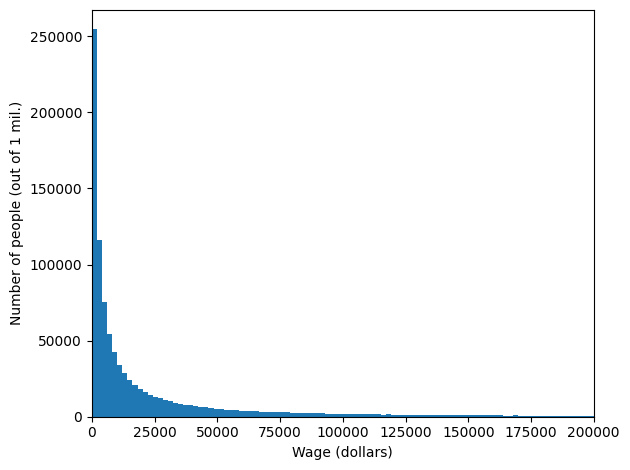

In [11]:
fig, ax = plt.subplots()
ax.hist(income, bins=bins)
ax.set_xlim(0, 200_000)
ax.set_ylabel("Number of people (out of 1 mil.)")
ax.set_xlabel("Wage (dollars)")
plt.tight_layout()
plt.show()

Let's also visualize the mean, median and the mode of this distribution.

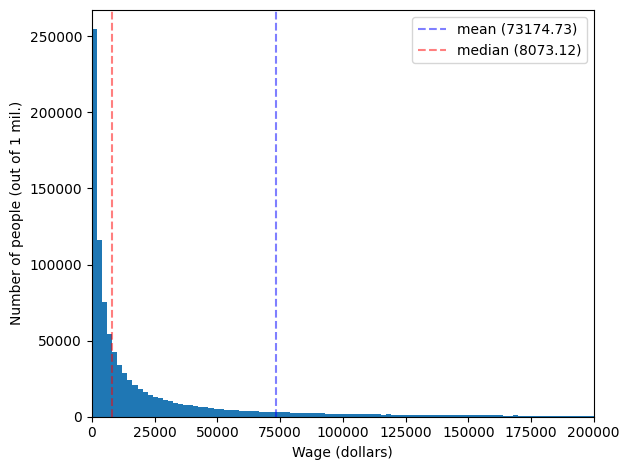

In [12]:
fig, ax = plt.subplots()
ax.hist(income, bins=bins)
ax.axvline(
    np.mean(income),
    linestyle="--",
    color="blue",
    alpha=0.5,
    label=f"mean ({np.mean(income):.2f})",
)
ax.axvline(
    np.median(income),
    linestyle="--",
    color="red",
    alpha=0.5,
    label=f"median ({np.median(income):.2f})",
)
ax.set_xlim(0, 200_000)
ax.set_ylabel("Number of people (out of 1 mil.)")
ax.set_xlabel("Wage (dollars)")
ax.legend()
plt.tight_layout()
plt.show()

So comparing the mean and the median, which one would be closer to the answer we would get if we asked people about their wages? It would probably be the median value. Because the mean is very sensitive to outliers, and we have ultra-rich people in the distribution, we cannot rely on it.

So what does this have to do with estimation? Nothing. I just wanted to make it clearer that the fact we can obtain the same result using both the mean and the median above is a property of the normal distribution. Let's keep going with the estmiation.

Let's check out means and medians first.

In [13]:
means[:5], medians[:5]

([np.float64(3.7188972967062064),
  np.float64(3.423018440394357),
  np.float64(3.7086133237146193),
  np.float64(3.5863881877540345),
  np.float64(3.6950035485128514)],
 [np.float64(3.4673341774949065),
  np.float64(3.971873301854166),
  np.float64(3.4650754763284177),
  np.float64(3.640032068567572),
  np.float64(3.777677780637166)])

We are sure that both mean and the median is a great estimators, but let's take a look at the RMSE (Root Mean Sqaure Error) of both estimates.

In [14]:
def mse(estimates, actual):
    errors = np.asarray(estimates) - actual
    return np.mean(errors**2)

In [15]:
means_rmse = np.sqrt(mse(means, mu))
medians_rmse = np.sqrt(mse(medians, mu))
means_rmse, medians_rmse

(np.float64(0.05445099630472849), np.float64(0.07342475093433003))

It looks like the RMSE of means is lower, which means the deviation of the sample means is lower compared to deviation of the sample medians.

## Robustness

The `mu` and the `sigma` we use here are from an imaginary penguin weight dataset.

If we expand on the scenario, we take the penguins, weigh them, and record their weights. However, let’s say that 2% of the penguins accidentally pressed the “unit” button, and some of them were measured in kilograms instead of pounds.

In [16]:
def make_normal_sample_with_errors(mu, sigma, n):
    sample = np.random.normal(mu, sigma, n)
    factor = np.random.choice([1, 1 / pound], p=[0.98, 0.02], size=n)
    return factor * sample

In [17]:
sample = make_normal_sample_with_errors(mu, sigma, 5000)
sample_pdf = pd.Series(sample).value_counts(normalize=True)

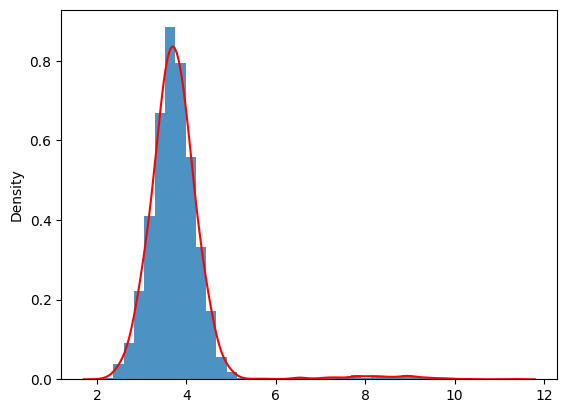

In [18]:
fig, ax = plt.subplots()
ax.hist(sample, bins=40, density=True, alpha=0.8)
sns.kdeplot(sample, ax=ax, color="red")
plt.show()

As we can see, the outliers are causing the plot to extend to the right. Let's see which estimator is unbiased with the faulty dataset.

In [19]:
ns = np.logspace(1, 5).astype(int)
faulty_means = [np.mean(make_normal_sample_with_errors(mu, sigma, n)) for n in ns]
faulty_medians = [np.median(make_normal_sample_with_errors(mu, sigma, n)) for n in ns]

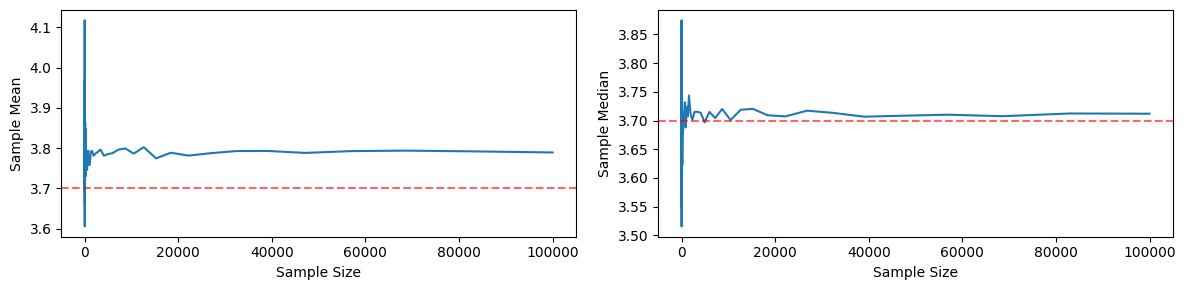

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(ns, faulty_means)
axes[1].plot(ns, faulty_medians)
axes[0].axhline(mu, linestyle="--", color="red", alpha=0.6)
axes[1].axhline(mu, linestyle="--", color="red", alpha=0.6)
axes[0].set_ylabel("Sample Mean")
axes[0].set_xlabel("Sample Size")
axes[1].set_ylabel("Sample Median")
axes[1].set_xlabel("Sample Size")
plt.tight_layout()
plt.show()

With the faulty dataset, median is the less biased estimator. That's because, as we've always been saying, the median is much more robust.

## Estimating Variance

Suppose we want to estimate the variance in the penguins' weights. But we also have to know that there are two ways of computing the variance, one is biased, and the other one is unbiased. Let's see the difference between them.

In [21]:
def biased_var(data):
    n = len(data)
    mean = np.mean(data)
    deviations = data - mean
    return np.mean(np.sum(deviations**2) / n)

In [22]:
biased_vars = [biased_var(make_normal_sample(mu, sigma, n=50)) for i in range(1001)]
np.mean(biased_vars), sigma**2

(np.float64(0.20726379500498626), 0.2116)

We know that our population variance is 0.2116, but `biased_vars` consistently gives an underestimation.

In [23]:
def unbiased_var(data):
    n = len(data)
    mean = np.mean(data)
    deviations = data - mean
    return np.mean(np.sum(deviations**2) / (n - 1))


unbiased_vars = [unbiased_var(make_normal_sample(mu, sigma, n=50)) for i in range(1001)]
np.mean(unbiased_vars), sigma**2

(np.float64(0.2121693366875035), 0.2116)

`unbiased_vars` gives us a much closer value to population variance. Because compared to the population, the data points are closer together in a sample, and because variance estimates deviation, we consistently overestimate the variance.

That's was the practical reason, there is also a mathematically proven reason which I'm not going to get into here.

## Sampling Distributions

So far we've been working with simulated data, now, let's see what happens with real data.

In [24]:
peng = (
    pd.read_csv("./data/penguins_raw.csv")
    .dropna(subset="Body Mass (g)")
    .reset_index(drop=True)
)

In [25]:
peng.shape
peng

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,2007-11-11,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,2007-11-11,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,2007-11-16,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,NaN
3,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,2007-11-16,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,NaN
4,PAL0708,6,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A2,Yes,2007-11-16,39.3,20.6,190.0,3650.0,MALE,8.66496,-25.29805,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
337,PAL0910,64,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N98A2,Yes,2009-11-19,55.8,19.8,207.0,4000.0,MALE,9.70465,-24.53494,NaN
338,PAL0910,65,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N99A1,No,2009-11-21,43.5,18.1,202.0,3400.0,FEMALE,9.37608,-24.40753,Nest never observed with full clutch.
339,PAL0910,66,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N99A2,No,2009-11-21,49.6,18.2,193.0,3775.0,MALE,9.46180,-24.70615,Nest never observed with full clutch.
340,PAL0910,67,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N100A1,Yes,2009-11-21,50.8,19.0,210.0,4100.0,MALE,9.98044,-24.68741,NaN


For this example, we are only going to use Chinstrap penguins.

In [26]:
chin = peng[peng["Species"] == "Chinstrap penguin (Pygoscelis antarctica)"]
chin

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
274,PAL0708,1,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N61A1,No,2007-11-19,46.5,17.9,192.0,3500.0,FEMALE,9.03935,-24.30229,Nest never observed with full clutch.
275,PAL0708,2,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N61A2,No,2007-11-19,50.0,19.5,196.0,3900.0,MALE,8.92069,-24.23592,Nest never observed with full clutch.
276,PAL0708,3,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N62A1,Yes,2007-11-26,51.3,19.2,193.0,3650.0,MALE,9.29078,-24.75570,NaN
277,PAL0708,4,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N62A2,Yes,2007-11-26,45.4,18.7,188.0,3525.0,FEMALE,8.64701,-24.62717,NaN
278,PAL0708,5,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N64A1,Yes,2007-11-21,52.7,19.8,197.0,3725.0,MALE,9.00642,-24.61867,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
337,PAL0910,64,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N98A2,Yes,2009-11-19,55.8,19.8,207.0,4000.0,MALE,9.70465,-24.53494,NaN
338,PAL0910,65,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N99A1,No,2009-11-21,43.5,18.1,202.0,3400.0,FEMALE,9.37608,-24.40753,Nest never observed with full clutch.
339,PAL0910,66,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N99A2,No,2009-11-21,49.6,18.2,193.0,3775.0,MALE,9.46180,-24.70615,Nest never observed with full clutch.
340,PAL0910,67,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N100A1,Yes,2009-11-21,50.8,19.0,210.0,4100.0,MALE,9.98044,-24.68741,NaN


In [27]:
chin["Body Mass (kg)"] = chin["Body Mass (g)"] / 1000
chin["Body Mass (kg)"]

274    3.500
275    3.900
276    3.650
277    3.525
278    3.725
       ...  
337    4.000
338    3.400
339    3.775
340    4.100
341    3.775
Name: Body Mass (kg), Length: 68, dtype: float64

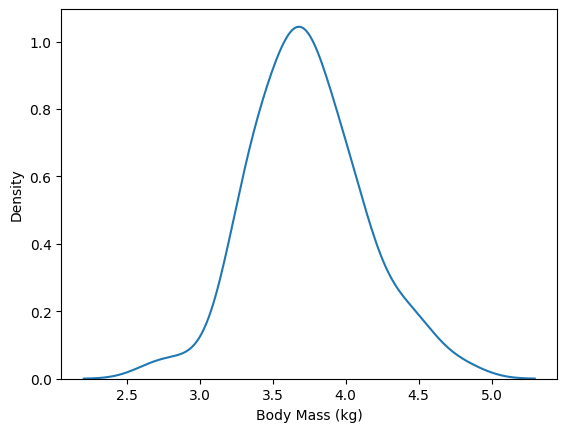

In [28]:
fig, ax = plt.subplots()
sns.kdeplot(chin["Body Mass (kg)"], ax=ax)
plt.show()

In [29]:
sample = chin["Body Mass (kg)"].sample(35)
np.mean(sample)

np.float64(3.7150000000000003)

So there are multiple methods which use resampling, we can generally use bootstrapping to estimate the population parameters, we can also use permutation tests for null hypothesis. But in this example, since we know about the population distribution, we are going to cheat and use parametric resampling, which also a form of bootstrapping but with more trust on mathematical model rather than the data.

In [30]:
def resample(sample):
    mean, std = np.mean(sample), np.std(sample)
    return np.random.normal(mean, std, len(sample))

In [31]:
sample_means = [np.mean(resample(sample)) for i in range(1001)]
sample_means[:5]

[np.float64(3.6604487600343965),
 np.float64(3.61511854281648),
 np.float64(3.781051777722146),
 np.float64(3.641188715597833),
 np.float64(3.75453085036075)]

In [32]:
np.mean(chin["Body Mass (kg)"]), np.mean(sample_means)

(np.float64(3.733088235294118), np.float64(3.7159811606358817))

This is the secnario where we try to estimate the dataset's parameters using a small part of dataset. But what if we wanted to estimate the overall parameters of the Chinstrap penguins at Antarctica, even with the ones that are not in the dataset.

In [33]:
sample_means_overall = [np.mean(resample(chin["Body Mass (kg)"])) for i in range(10000)]
np.mean(sample_means_overall)

np.float64(3.7326064874049765)

Not surprisingly, we are going to see a normal distribution for the distribution of the means.

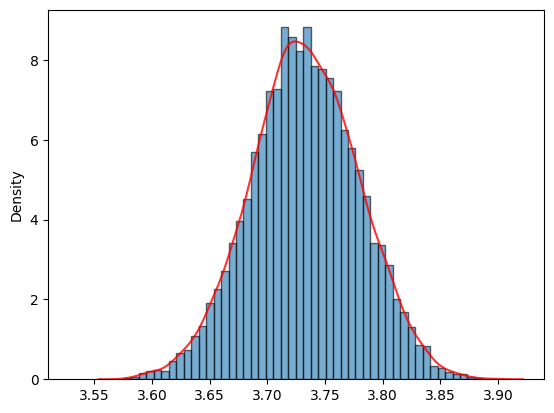

In [34]:
fig, ax = plt.subplots()
sample_means_overall_df = pd.Series(sample_means_overall)
ax.hist(sample_means_overall_df, bins=50, alpha=0.6, edgecolor="black", density=True)
sns.kdeplot(sample_means_overall, ax=ax, color="red", alpha=0.8)
ax.set_xlim(3.51)
plt.show()

## Standard Error

We know that standard deviation measures the spread, but to use the correct terminology, standard deviation of the sample means is called _standard error_. Let's compute that.

In [35]:
print("Std. Err.", np.std(sample_means_overall))

Std. Err. 0.046598775624229975


Which translates to, "if we collect many samples, we expect sample means to vary by about the above value, on average."

## Confidence Intervals

Another way of summarizing sampling distributions is to compute a confidence interval. For example, 90% confidence interval contains 90% of the values in the sampling distribution.

In [36]:
np.percentile(sample_means_overall, [5, 95])

array([3.6553225 , 3.80916597])

## Exercies

Let's find the sampling distribution of the standard deviation for Chinstrap penguins

In [37]:
chin

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments,Body Mass (kg)
274,PAL0708,1,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N61A1,No,2007-11-19,46.5,17.9,192.0,3500.0,FEMALE,9.03935,-24.30229,Nest never observed with full clutch.,3.500
275,PAL0708,2,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N61A2,No,2007-11-19,50.0,19.5,196.0,3900.0,MALE,8.92069,-24.23592,Nest never observed with full clutch.,3.900
276,PAL0708,3,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N62A1,Yes,2007-11-26,51.3,19.2,193.0,3650.0,MALE,9.29078,-24.75570,NaN,3.650
277,PAL0708,4,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N62A2,Yes,2007-11-26,45.4,18.7,188.0,3525.0,FEMALE,8.64701,-24.62717,NaN,3.525
278,PAL0708,5,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N64A1,Yes,2007-11-21,52.7,19.8,197.0,3725.0,MALE,9.00642,-24.61867,NaN,3.725
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
337,PAL0910,64,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N98A2,Yes,2009-11-19,55.8,19.8,207.0,4000.0,MALE,9.70465,-24.53494,NaN,4.000
338,PAL0910,65,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N99A1,No,2009-11-21,43.5,18.1,202.0,3400.0,FEMALE,9.37608,-24.40753,Nest never observed with full clutch.,3.400
339,PAL0910,66,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N99A2,No,2009-11-21,49.6,18.2,193.0,3775.0,MALE,9.46180,-24.70615,Nest never observed with full clutch.,3.775
340,PAL0910,67,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N100A1,Yes,2009-11-21,50.8,19.0,210.0,4100.0,MALE,9.98044,-24.68741,NaN,4.100


In [38]:
def bootstrap(sample):
    return np.random.choice(sample, len(sample), replace=True)

In [39]:
chin_std_distribution = [
    np.std(bootstrap(chin["Body Mass (kg)"]), ddof=1) for _ in range(10000)
]
chin_std_distribution

[np.float64(0.37517244352334844),
 np.float64(0.3605587420282983),
 np.float64(0.3988300149393294),
 np.float64(0.367417487586495),
 np.float64(0.37579207393959346),
 np.float64(0.4431497427155208),
 np.float64(0.4024703881046919),
 np.float64(0.33972032472938757),
 np.float64(0.39632032255295857),
 np.float64(0.3572212224321593),
 np.float64(0.41143926057786934),
 np.float64(0.3813092309233509),
 np.float64(0.47148423364141456),
 np.float64(0.34983848022706926),
 np.float64(0.41439656324951757),
 np.float64(0.41050663038600144),
 np.float64(0.36014912376967295),
 np.float64(0.38473445998130024),
 np.float64(0.44372190583636023),
 np.float64(0.4140602559077459),
 np.float64(0.36729649660446045),
 np.float64(0.4568080447756252),
 np.float64(0.35521539886012454),
 np.float64(0.365833984138754),
 np.float64(0.3730794763238558),
 np.float64(0.35789627588624007),
 np.float64(0.4074083152538934),
 np.float64(0.3756213757368553),
 np.float64(0.4132243487250964),
 np.float64(0.3561595448368639

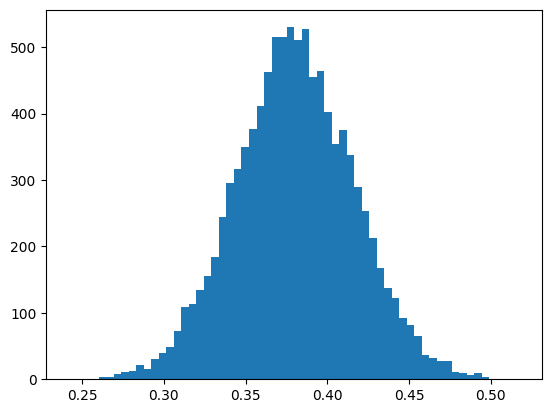

In [40]:
fig, ax = plt.subplots()
ax.hist(chin_std_distribution, bins=60)
plt.show()

In [41]:
np.mean(chin_std_distribution), np.std(chin["Body Mass (kg)"], ddof=1)

(np.float64(0.3802841595794635), np.float64(0.3843350813871914))